In [16]:
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T # 图像预处理转换

In [6]:
# 1. 加载图像
image = Image.open("Apple.jpg")
print(image.size)

(600, 574)


In [7]:
# 定义图像转换操作
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

# 2. 应用转换操作，转换成模型需要的张量
img_tensor = transform(image)
print(img_tensor.shape)

torch.Size([3, 256, 256])


In [9]:
# 3. 转换成ndarry，方便画图
img_array = img_tensor.permute(1, 2, 0).numpy()
print(img_array.shape)

(256, 256, 3)


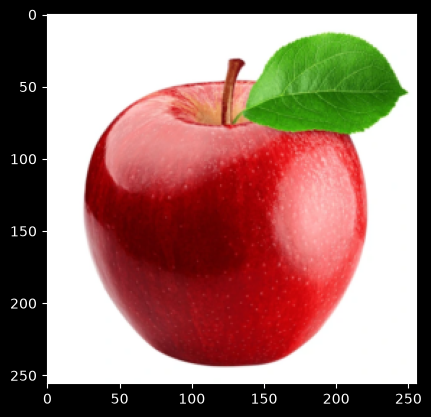

In [12]:
# 画图
plt.imshow(img_array)
plt.show()

In [13]:
print(img_tensor)

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])


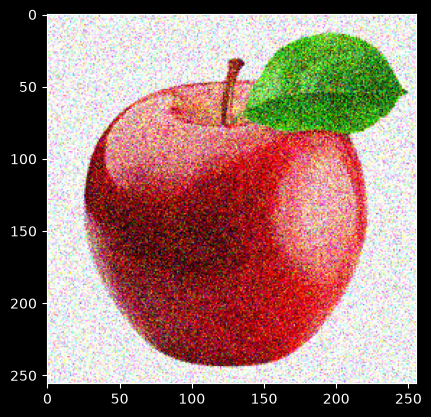

In [15]:
# 4. 在原图像上添加噪声
img_noise = img_tensor + torch.randn_like(img_tensor) * 0.2
img_noise = img_noise.clamp(0.0, 1.0)
img_noise_array = img_noise.permute(1, 2, 0).numpy()
plt.imshow(img_noise_array)
plt.show()

## 搭建模型

In [24]:
# 自定义自编码架构
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # 编码器
        self.encoder = nn.Sequential(
            # 第一层卷积-池化
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 第二层卷积池化
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.decoder = nn.Sequential(
            # 第一层转置卷积
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # 第二层转置卷积
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    # 前向传播
    def forward(self, x):
        # 编码
        x = self.encoder(x)
        # print("encoded shape: ", x.shape)
        # 解码
        x = self.decoder(x)
        # print("decoded-shape: ", x.shape)
        return x

In [25]:
model = Autoencoder()

In [26]:
# 前向传播测试
output = model(img_tensor)
print(output.shape)

torch.Size([3, 256, 256])


## 模型训练

In [27]:
# 1. 定义设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

In [28]:
# 2. 定义超参数
lr = 0.001
epochs = 400

In [29]:
# 3. 定义损失函数和优化器
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [30]:
# 4. 循环迭代，开始训练
for epoch in range(epochs):
    input = img_noise.to(device)
    target = img_tensor.to(device)
    # 前向传播
    output = model(input)
    # 计算损失
    loss = loss_fn(output, target)
    # 反向传播
    loss.backward()
    # 更新参数
    optimizer.step()
    # 梯度清零
    optimizer.zero_grad()
    # 每50轮打印一次损失
    if (epoch + 1) % 20 == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item():.4f}')

Epoch: 19, Loss: 0.1714
Epoch: 39, Loss: 0.1112
Epoch: 59, Loss: 0.0620
Epoch: 79, Loss: 0.0334
Epoch: 99, Loss: 0.0240
Epoch: 119, Loss: 0.0194
Epoch: 139, Loss: 0.0166
Epoch: 159, Loss: 0.0148
Epoch: 179, Loss: 0.0133
Epoch: 199, Loss: 0.0121
Epoch: 219, Loss: 0.0111
Epoch: 239, Loss: 0.0104
Epoch: 259, Loss: 0.0098
Epoch: 279, Loss: 0.0094
Epoch: 299, Loss: 0.0090
Epoch: 319, Loss: 0.0086
Epoch: 339, Loss: 0.0083
Epoch: 359, Loss: 0.0080
Epoch: 379, Loss: 0.0077
Epoch: 399, Loss: 0.0073


In [31]:
# 模型保存
torch.save(model.state_dict(), 'model.pt')

In [32]:
state_dict = torch.load('model.pt')
model.load_state_dict(state_dict)

<All keys matched successfully>

## 测试（推理）

In [33]:
with torch.no_grad():
    input = img_noise.to(device)
    # 前向传播，得到预测输出（重构图像）
    output = model(input)
print(output)

tensor([[[0.9389, 0.9525, 0.9491,  ..., 0.9525, 0.9219, 0.7730],
         [0.9669, 0.9697, 0.9568,  ..., 0.9855, 0.9663, 0.8780],
         [0.9579, 0.9748, 0.9848,  ..., 0.9898, 0.9899, 0.8787],
         ...,
         [0.9488, 0.9542, 0.9507,  ..., 0.9562, 0.9306, 0.8387],
         [0.8903, 0.9578, 0.9699,  ..., 0.9567, 0.9441, 0.7843],
         [0.7756, 0.8601, 0.8232,  ..., 0.8182, 0.7718, 0.7225]],

        [[0.8308, 0.8605, 0.8792,  ..., 0.9251, 0.8988, 0.8031],
         [0.8879, 0.8995, 0.8853,  ..., 0.9331, 0.8904, 0.8545],
         [0.8805, 0.9044, 0.8968,  ..., 0.9455, 0.9687, 0.8789],
         ...,
         [0.8542, 0.8979, 0.8949,  ..., 0.9088, 0.8453, 0.7965],
         [0.8436, 0.8529, 0.8933,  ..., 0.8448, 0.8959, 0.7348],
         [0.7873, 0.8972, 0.8221,  ..., 0.7881, 0.7336, 0.6641]],

        [[0.8745, 0.8996, 0.9229,  ..., 0.9501, 0.9335, 0.8500],
         [0.9057, 0.9216, 0.9206,  ..., 0.9454, 0.9654, 0.9504],
         [0.9164, 0.9199, 0.9214,  ..., 0.9802, 0.9756, 0.

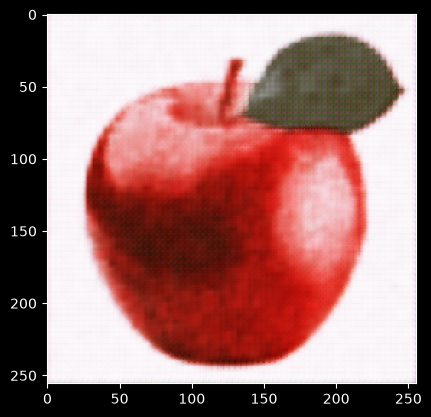

In [34]:
img_recon_array = output.cpu().permute(1, 2, 0).numpy()
plt.imshow(img_recon_array)
plt.show()